### **Human Ovary Atlas - Metadata cleaning, classification, and covariate preparation** ###
**Written by:** Josef Byrne

**Purpose:** Clean, classify, and export donor-level metadata for downstream analyses.

In [ ]:
# Imports & Settings
import sys
sys.path.append('/path/to/utils/directory')
from utils_OvaryAtlas import get_session_info

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from textwrap import fill
import scipy.stats as ss
from statsmodels.stats.multitest import multipletests
import warnings


from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42

In [ ]:
# Define directories
nostromo_datadir="/path/to/project_directory"
python_analyses_dir = f"{nostromo_datadir}/python_analyses"

In [4]:
# Read the Excel file into a pandas DataFrame
metadata_df = pd.read_csv(f"{nostromo_datadir}/raw_ovary_metadata_dispersed.csv")

#### Demographic metadata ####

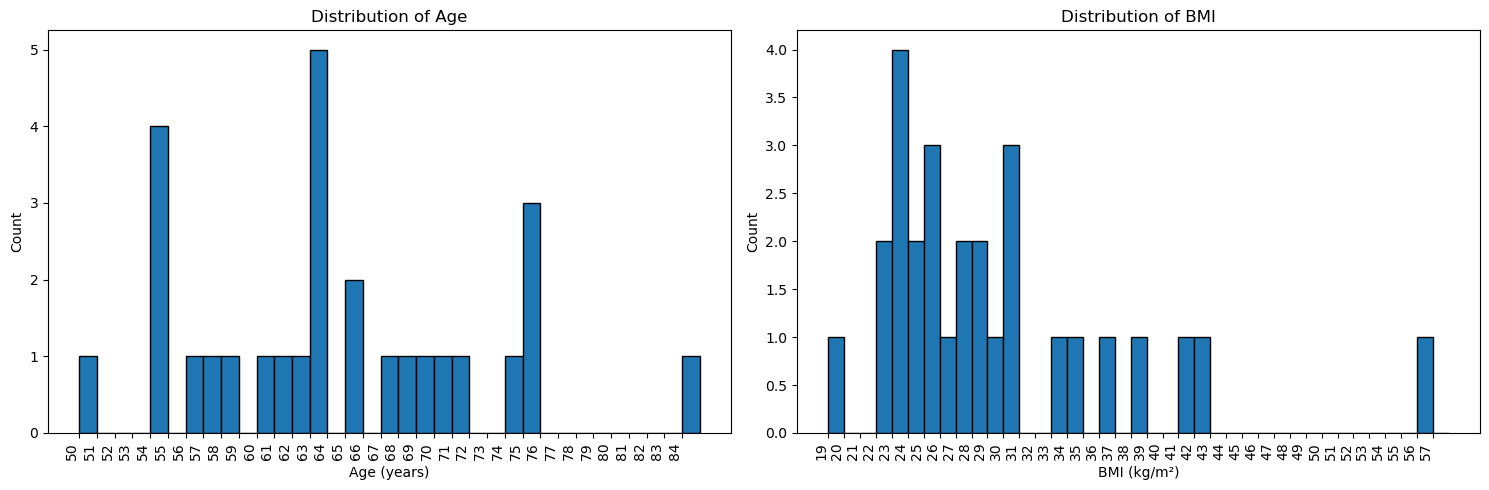


Age Statistics:
count    28.000000
mean     64.035714
std       8.117116
min      50.000000
25%      57.750000
50%      63.000000
75%      69.250000
max      84.000000
Name: Age(yr), dtype: float64

BMI Statistics:
count    28.000000
mean     29.489286
std       7.938949
min      19.800000
25%      24.150000
50%      27.850000
75%      31.250000
max      56.900000
Name: BMI(kg*m^-2), dtype: float64


In [6]:
# Plot age and BMI distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Age distribution
# Bin for every year of age and label every year on the x-axis
age_col = metadata_df['Age(yr)']
min_age, max_age = int(age_col.min()), int(age_col.max())
bins = range(min_age, max_age + 2)  # +2 to include the last year as the rightmost edge

axes[0].hist(age_col, bins=bins, edgecolor='black')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(min_age, max_age + 1))
axes[0].set_xticklabels(range(min_age, max_age + 1), rotation=90, ha='right')

# Plot BMI distribution where every integer BMI value gets its own bar
bmi_col = metadata_df['BMI(kg*m^-2)']
min_bmi, max_bmi = int(np.floor(bmi_col.min())), int(np.ceil(bmi_col.max()))
bmi_bins = np.arange(min_bmi, max_bmi + 2)  # +2 so last value is a full bar

axes[1].hist(bmi_col, bins=bmi_bins, edgecolor='black')
axes[1].set_title('Distribution of BMI')
axes[1].set_xlabel('BMI (kg/m²)')
axes[1].set_ylabel('Count')
axes[1].set_xticks(np.arange(min_bmi, max_bmi + 1))
axes[1].set_xticklabels(np.arange(min_bmi, max_bmi + 1), rotation=90, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nAge Statistics:")
print(metadata_df['Age(yr)'].describe())
print("\nBMI Statistics:")
print(metadata_df['BMI(kg*m^-2)'].describe())


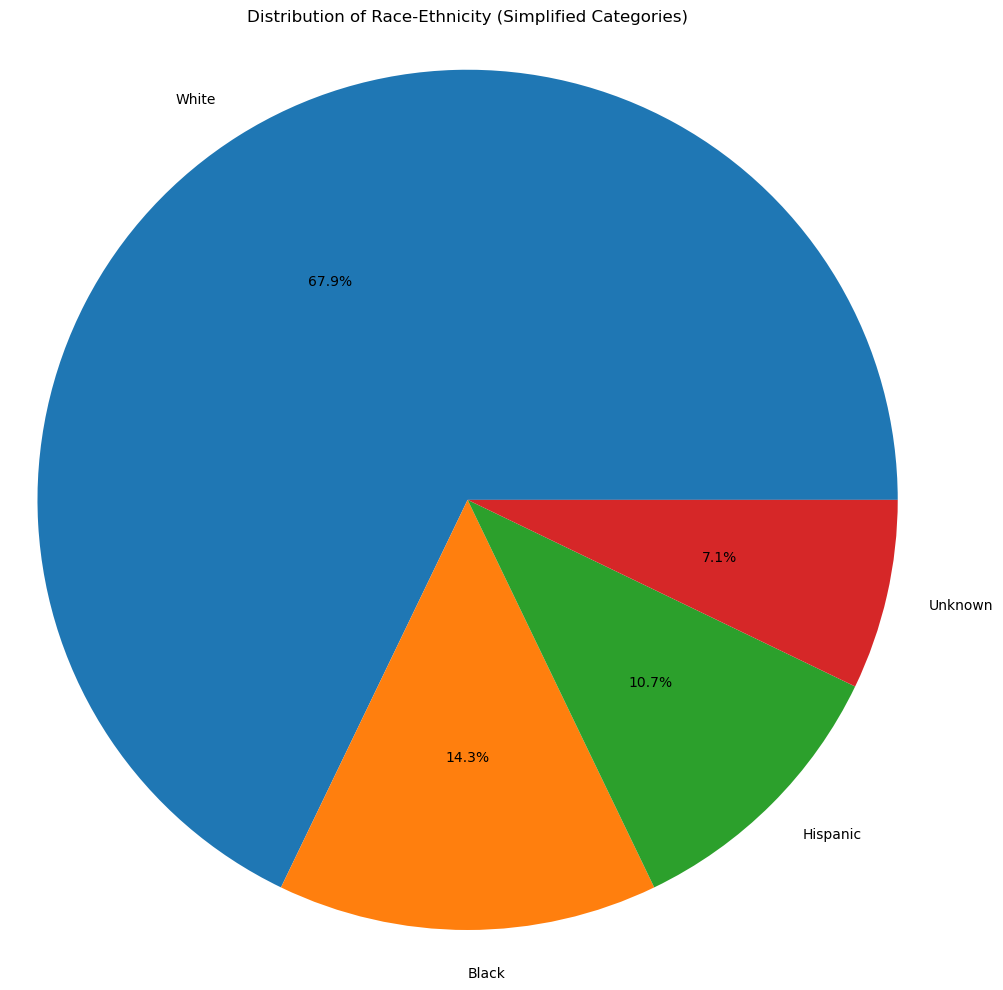


Simplified Race-Ethnicity Distribution:
Simplified_Race_Ethnicity
White       19
Black        4
Hispanic     3
Unknown      2
Name: count, dtype: int64


In [7]:
# Create a new column for simplified race/ethnicity categories
metadata_df['Simplified_Race_Ethnicity'] = metadata_df.apply(lambda row:
    'Hispanic' if row['Ethnicity'] == 'Hispanic/Latino'
    else row['Race'] if row['Race'] in ['White', 'Asian']
    else 'Black' if row['Race'] == 'Black/African American'
    else 'Unknown', axis=1)

# Plot the distribution as a pie chart
plt.figure(figsize=(10, 10))
simplified_counts = metadata_df['Simplified_Race_Ethnicity'].value_counts()
plt.pie(simplified_counts.values, labels=simplified_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Race-Ethnicity (Simplified Categories)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.tight_layout()
plt.show()

# Print the counts
print("\nSimplified Race-Ethnicity Distribution:")
print(simplified_counts)


#### Pregnancy-associated metadata ####

In [ ]:
# Review pregnancy outcome metadata

# Convert relevant columns to integers, handling NaN values
for col in ['Gravida', 'Para', 'Number_of_Children']:
    metadata_df[col] = pd.to_numeric(metadata_df[col], errors='coerce')

# Check if Number_of_Children matches Para for each row
mismatches = metadata_df[metadata_df['Number_of_Children'] != metadata_df['Para']]
print("\nRows where Number_of_Children doesn't match Para:")
print(mismatches[['SenNet_ID', 'Number_of_Children', 'Para', 'Gravida']])

# Aside from two missing Number_of_Children values, all available values match Para.
# Para is therefore used as the live-birth count variable for downstream analyses.


Rows where Number_of_Children doesn't match Para:
   SenNet_ID  Number_of_Children  Para  Gravida
19   SN_0168                 NaN     3        5
20   SN_0169                 NaN     3        3


In [9]:
# Calculate a para/gravida ratio that may be suggestive of reproductive health,
# but without additional information regarding reasons for loss of pregnancy may be misleading.

# Calculate gravida/para ratio & put right after Para column
para_col_idx = metadata_df.columns.get_loc('Para')
metadata_df.insert(para_col_idx + 1, 'Para_Gravida_Ratio',
    metadata_df.apply(lambda row: row['Para'] / row['Gravida'] if row['Gravida'] > 0 else np.nan, axis=1))

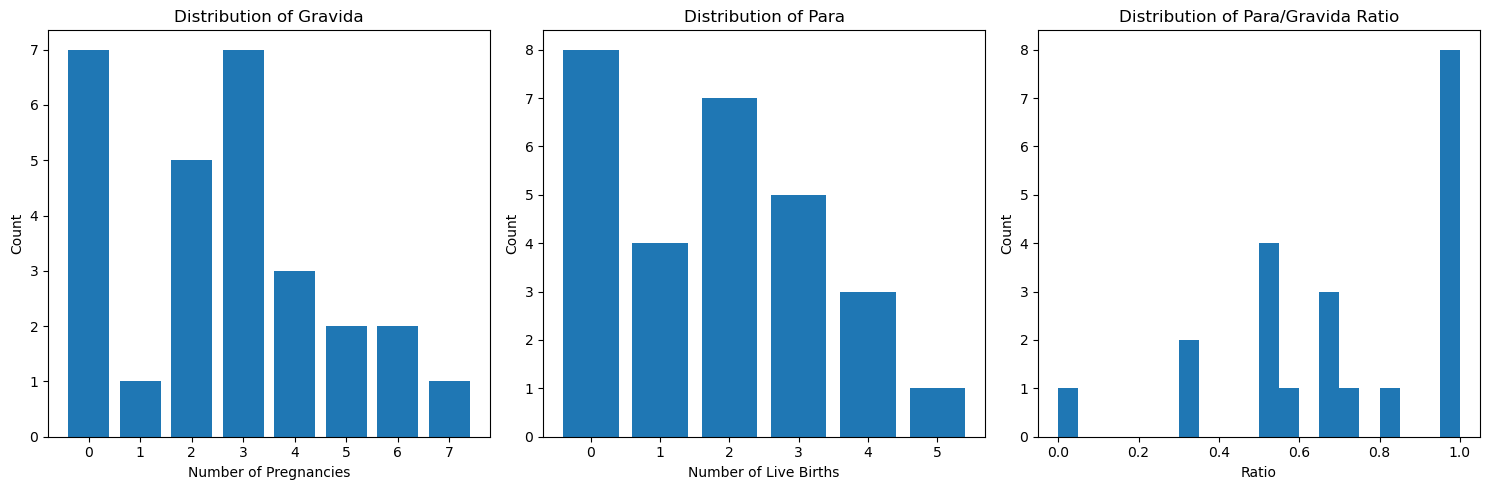

In [10]:
# Plot distribution of pregnancy-related metadata
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Gravida distribution
gravida_counts = metadata_df['Gravida'].value_counts().sort_index()
axes[0].bar(gravida_counts.index, gravida_counts.values)
axes[0].set_title('Distribution of Gravida')
axes[0].set_xlabel('Number of Pregnancies')
axes[0].set_ylabel('Count')

# Plot Para distribution
para_counts = metadata_df['Para'].value_counts().sort_index()
axes[1].bar(para_counts.index, para_counts.values)
axes[1].set_title('Distribution of Para')
axes[1].set_xlabel('Number of Live Births')
axes[1].set_ylabel('Count')

# Plot Para/Gravida Ratio distribution with better granularity
ratio_data = metadata_df['Para_Gravida_Ratio'].dropna()

# Create a histogram with more bins for better granularity
axes[2].hist(ratio_data, bins=20)
axes[2].set_title('Distribution of Para/Gravida Ratio')
axes[2].set_xlabel('Ratio')
axes[2].set_ylabel('Count')

# Set x-axis limits to show only the actual data range
axes[2].set_xlim(ratio_data.min() - 0.05, ratio_data.max() + 0.05)

plt.tight_layout()
plt.show()


#### Diagnosis-associated metadata ####

In [11]:
# --- Function to apply classifications to metadata  --

# --- Helper Function for Cleaning Text  ---
def clean_term(term_val):
    """Cleans and standardizes a text term."""
    if pd.isna(term_val) or not isinstance(term_val, str):
        return ""
    term_lower = term_val.lower()
    term_lower = term_lower.replace('hyperplsia', 'hyperplasia')
    term_lower = term_lower.replace('\xa0', ' ').strip()
    return term_lower

# --- Parser for 'Diagnoses'  ---
def parse_diagnoses_column(term_val):
    flags = set()
    term = clean_term(term_val)
    if not term: return list(flags)

    # Uterine/Endometrial Malignancy
    if "endometrial cancer" in term or \
       "endometrioid adenocarcinoma" in term or \
       "endometrial adenocarcinoma" in term:
        flags.add("Malignant_Uterine")

    # Cervical Malignancy
    if "malignant neoplasm of exocervix" in term or \
       ("malignant neoplasm" in term and "cervix" in term):
        flags.add("Malignant_Cervical")

    # Uterine/Endometrial Premalignancy
    if "atypical endometrial hyperplasia" in term or \
       "endometrial intraepithelial neoplasia" in term or \
       "hyperplasia with atypia" in term or \
       ("complex atypical" in term and "hyperplasia" in term):
        flags.add("Premalignant_Uterine")

    if ("cervical" in term and "intraepithelial neoplasia" in term and "endometrial" not in term) or \
       ("cervical" in term and "dysplasia" in term) or \
       ("severe dysplasia" in term and "cervical" in term):
        flags.add("Premalignant_Cervical")

    # Pelvic Organ Prolapse
    if "prolapse" in term:
        flags.add("Pelvic_Organ_Prolapse")

    # Urinary Incontinence
    if "sui" in term or "stress urinary incontinence" in term or \
       "urge urinary incontinence" in term or \
       "mixed incontinence" in term or "urinary incontinence" in term:
        flags.add("Urinary_Incontinence")

    # Symptoms/Findings
    if "post menopausal bleeding" in term or "post-menopausal bleeding" in term:
        flags.add("Symptom_Bleeding")
    if "endometrial thickening" in term:
        flags.add("Endometrial_Thickening")

    # Benign Ovarian flags in diagnoses column
    if "cyst of left ovary" in term or "ovarian cyst" in term:
        flags.add("Ovarian_Specific_Benign_Finding")

    return list(flags)

# --- Parser for 'Ovarian_Final_Pathology'  ---
def parse_ovarian_final_pathology(term_val):
    flags = set()
    term = clean_term(term_val)
    if not term: return list(flags)

    # is_benign_ovarian_by_path_keyword = False

    specific_findings_keywords_path = [
        "adhesions", "decidualization", "cyst"
    ]
    if any(keyword in term for keyword in specific_findings_keywords_path):
        flags.add("Ovarian_Specific_Benign_Finding")

    # Only benign ovaries (with no overt malignancy or premalignancy by pathologist assessment) used for this study
    flags.add("Benign_Ovarian")

    return list(flags)

In [12]:
# --- Apply Classifications  --

# Check if the required source columns exist in the DataFrame
diagnosis_columns = ['Diagnoses', 'Ovarian_Final_Pathology']

# Define all potential new classification columns
diagnosis_classification_columns = sorted(list(set([
    "Malignant_Uterine", "Premalignant_Uterine", "Benign_Uterine",
    "Malignant_Cervical", "Premalignant_Cervical", "Benign_Cervical",
    "Malignant_Ovarian", "Premalignant_Ovarian", "Benign_Ovarian",
    "Ovarian_Specific_Benign_Finding",
    "Pelvic_Organ_Prolapse", "Urinary_Incontinence",
    "Symptom_Bleeding", "Endometrial_Thickening"
])))

# Initialize new classification columns in DataFrame with 'N'
for col in diagnosis_classification_columns:
    metadata_df[col] = 'N'

# Main processing loop to iterate through DataFrame rows
for index, row in metadata_df.iterrows():
    combined_flags_for_row = set()

    # Extract text from each source column for the current row
    # Using .get(col, None) ensures that if a column is somehow missing for a row, it defaults to None, which clean_term handles.
    term_diag_val = row.get('Diagnoses', None)
    term_ovpath_val = row.get('Ovarian_Final_Pathology', None)

    # Process all source columns to gather explicit flags
    flags_diag = parse_diagnoses_column(term_diag_val)
    combined_flags_for_row.update(flags_diag)

    flags_ovpath = parse_ovarian_final_pathology(term_ovpath_val)
    combined_flags_for_row.update(flags_ovpath)

    # Determine if row had any textual input before implicit benign logic
    row_had_textual_input = False
    if isinstance(term_diag_val, str) and clean_term(term_diag_val): row_had_textual_input = True
    if isinstance(term_ovpath_val, str) and clean_term(term_ovpath_val): row_had_textual_input = True

    # --- Enforce Hierarchy for Uterine/Endometrial conditions ---
    if "Malignant_Uterine" in combined_flags_for_row:
        flags_to_remove = {"Premalignant_Uterine", "Benign_Uterine"}
        combined_flags_for_row.difference_update(flags_to_remove)
    elif "Premalignant_Uterine" in combined_flags_for_row:
        flags_to_remove = {"Benign_Uterine"}
        combined_flags_for_row.difference_update(flags_to_remove)

    # --- Apply Implicit Benign Logic (after hierarchy enforcement) ---
    # Uterus/Endometrium
    if not any(f in combined_flags_for_row for f in ["Malignant_Uterine", "Premalignant_Uterine"]):
        combined_flags_for_row.add("Benign_Uterine")
    # Cervix
    if not any(f in combined_flags_for_row for f in ["Malignant_Cervical", "Premalignant_Cervical"]):
        combined_flags_for_row.add("Benign_Cervical")
    # Ovary
    if not any(f in combined_flags_for_row for f in ["Malignant_Ovarian", "Premalignant_Ovarian"]):
        combined_flags_for_row.add("Benign_Ovarian")

    # Populate the DataFrame columns with 'Y' for all accumulated flags (explicit + implicit)
    for flag_col in combined_flags_for_row:
        if flag_col in metadata_df.columns: # Ensure the flag corresponds to an actual column
            metadata_df.loc[index, flag_col] = 'Y'

print("Classification processing complete.")

Classification processing complete.


In [ ]:
metadata_df.head()

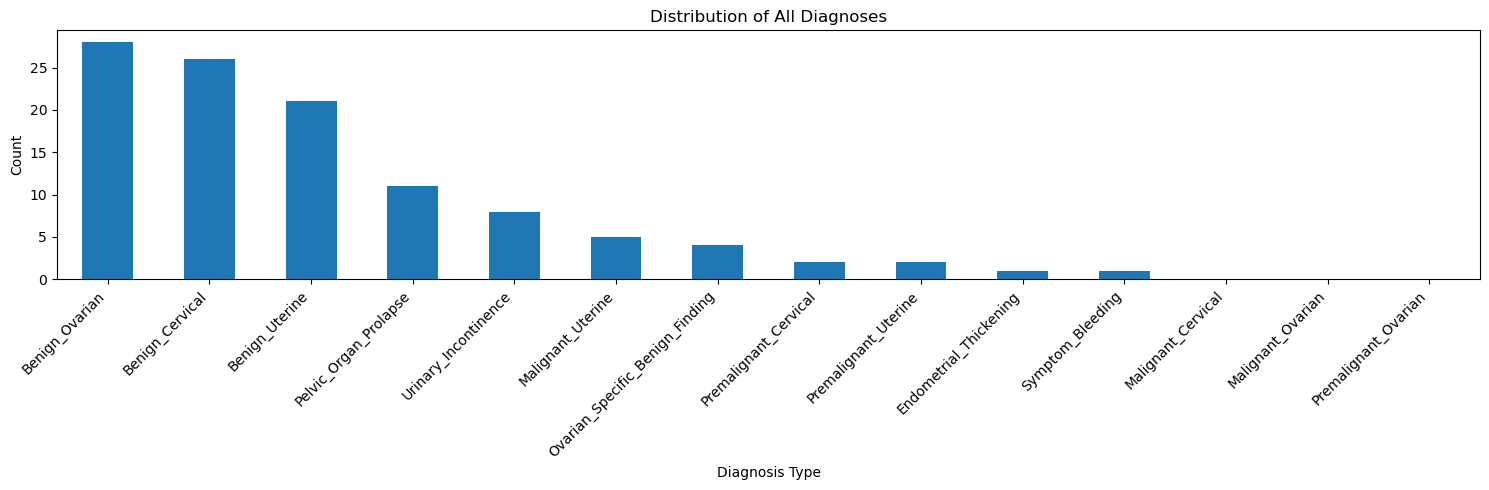

In [14]:
# Plot distribution of diagnoses classifications
fig, ax = plt.subplots(figsize=(15, 5))

# Diagnosis columns
diagnosis_cols = ['SenNet_ID', 'Diagnoses', 'Ovarian_Final_Pathology', 'Non-Ovarian_Cancer_State']

# Create a formatted view
formatted_df = metadata_df[diagnosis_cols + diagnosis_classification_columns].copy()
formatted_df = formatted_df.sort_index()

# Get counts for each classification type
diagnosis_counts = formatted_df[diagnosis_classification_columns].apply(lambda x: (x == 'Y').sum())

# Sort counts in descending order
diagnosis_counts = diagnosis_counts.sort_values(ascending=False)

# Bar plot of all diagnoses (note diagnoses are not all mutually exclusive)
diagnosis_counts.plot(kind='bar', ax=ax)
ax.set_title('Distribution of All Diagnoses')
ax.set_xlabel('Diagnosis Type')
ax.set_ylabel('Count')
ax.set_xticks(range(len(diagnosis_counts.index)))
ax.set_xticklabels(diagnosis_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show();


In [15]:
# Check for misalignment between Non-Ovarian Cancer State and organ-specific flags
print("\nChecking for misalignments between Non-Ovarian Cancer State and organ-specific flags...")
print("=" * 80)

# Initialize a list to store misalignments
misalignments = []

# Check each row for misalignments
for idx, row in metadata_df.iterrows():
    cancer_state = row['Non-Ovarian_Cancer_State']
    if pd.isna(cancer_state):
        continue

    # Get the actual organ states
    cervical_states = {
        'Benign': row.get('Benign_Cervical', 'N') == 'Y',
        'Premalignant': row.get('Premalignant_Cervical', 'N') == 'Y',
        'Malignant': row.get('Malignant_Cervical', 'N') == 'Y'
    }

    uterine_states = {
        'Benign': row.get('Benign_Uterine', 'N') == 'Y',
        'Premalignant': row.get('Premalignant_Uterine', 'N') == 'Y',
        'Malignant': row.get('Malignant_Uterine', 'N') == 'Y'
    }

    # Determine the maximum severity across both organs
    # Priority: Malignant > Premalignant > Benign
    max_severity = 'Benign'  # Default

    if cervical_states['Malignant'] or uterine_states['Malignant']:
        max_severity = 'Malignant'
    elif cervical_states['Premalignant'] or uterine_states['Premalignant']:
        max_severity = 'Premalignant'
    elif cervical_states['Benign'] or uterine_states['Benign']:
        max_severity = 'Benign'

    # Convert max_severity to match the Non-Ovarian_Cancer_State format
    expected_cancer_state = {
        'Malignant': 'Malignant',
        'Premalignant': 'Pre-malignant',
        'Benign': 'Benign'
    }[max_severity]

    # Check for misalignment
    if cancer_state != expected_cancer_state:
        # Get the active flags for display
        cervical_flags = [k for k, v in cervical_states.items() if v]
        uterine_flags = [k for k, v in uterine_states.items() if v]

        misalignments.append({
            'SenNet_ID': row['SenNet_ID'],
            'Non-Ovarian_Cancer_State': cancer_state,
            'Expected_State': expected_cancer_state,
            'Cervical_Flags': cervical_flags,
            'Uterine_Flags': uterine_flags
        })

# Display results
if misalignments:
    print(f"\nFound {len(misalignments)} misalignments:")
    for mis in misalignments:
        print(f"\nSenNet_ID: {mis['SenNet_ID']}")
        print(f"Diagnoses: {metadata_df.loc[metadata_df['SenNet_ID'] == mis['SenNet_ID'], 'Diagnoses'].iloc[0]}")
        print(f"Non-Ovarian_Cancer_State: {mis['Non-Ovarian_Cancer_State']}")
        print(f"Expected based on organ flags: {mis['Expected_State']}")
        print(f"Cervical flags: {', '.join(mis['Cervical_Flags']) if mis['Cervical_Flags'] else 'None'}")
        print(f"Uterine flags: {', '.join(mis['Uterine_Flags']) if mis['Uterine_Flags'] else 'None'}")
else:
    print("\nNo misalignments found between Non-Ovarian Cancer State and organ-specific flags.")
    print("All Non-Ovarian_Cancer_State values correctly reflect the maximum severity across cervical and uterine organs.")



Checking for misalignments between Non-Ovarian Cancer State and organ-specific flags...

Found 2 misalignments:

SenNet_ID: SN_0164
Diagnoses: endometrial hyperplsia
Non-Ovarian_Cancer_State: Malignant
Expected based on organ flags: Benign
Cervical flags: Benign
Uterine flags: Benign

SenNet_ID: SN_0170
Diagnoses: endometrial intraepithelial neoplasia
Non-Ovarian_Cancer_State: Benign
Expected based on organ flags: Pre-malignant
Cervical flags: Benign
Uterine flags: Premalignant


In [ ]:
# SN_0164 - per ACOG2023 and WHO guidelines, "endometrial hyperplsia" with no note of atypia is an incomplete diagnosis and
# is contradictory to "Malignant" note for same patient. Considering surgery performed and explicit note of malignancy, adjusting
# flags to align with a malignant endometrial carcinoma diagnosis. Adjusting flags appropriately.
metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0164', 'Malignant_Uterine'] = 'Y'
metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0164', 'Benign_Uterine'] = 'N'

# SN_0170 - per ACOG2023 and WHO guidelines, "endometrial intraepithelial neoplasia" (EIN) (previously "atypical endometrial hyperplasia") is a Pre-Malignant condition, not Benign.
# No alternative indication for the performed surgical procedure was noted in the available metadata.
# Adjusting flags to align with a pre-malignant EIN diagnosis.
metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0170', 'Non-Ovarian_Cancer_State'] = 'Pre-malignant'

# Display updated results for both samples
for sample_id in ['SN_0164', 'SN_0170']:
    print(f"\nSenNet_ID: {sample_id}")
    print(f"Diagnoses: {metadata_df.loc[metadata_df['SenNet_ID'] == sample_id, 'Diagnoses'].iloc[0]}")
    print(f"Non-Ovarian_Cancer_State: {metadata_df.loc[metadata_df['SenNet_ID'] == sample_id, 'Non-Ovarian_Cancer_State'].iloc[0]}")

    # Get active flags for display
    cervical_flags = [col for col in metadata_df.columns if 'Cervical' in col and metadata_df.loc[metadata_df['SenNet_ID'] == sample_id, col].iloc[0] == 'Y']
    uterine_flags = [col for col in metadata_df.columns if 'Uterine' in col and metadata_df.loc[metadata_df['SenNet_ID'] == sample_id, col].iloc[0] == 'Y']

    print(f"Cervical flags: {', '.join(cervical_flags) if cervical_flags else 'None'}")
    print(f"Uterine flags: {', '.join(uterine_flags) if uterine_flags else 'None'}")


SenNet_ID: SN_0164
Diagnoses: endometrial hyperplsia
Non-Ovarian_Cancer_State: Malignant
Cervical flags: Benign_Cervical
Uterine flags: Malignant_Uterine

SenNet_ID: SN_0170
Diagnoses: endometrial intraepithelial neoplasia
Non-Ovarian_Cancer_State: Pre-malignant
Cervical flags: Benign_Cervical
Uterine flags: Premalignant_Uterine


In [17]:
# SN_0238 - explicitly notes "high suspicion of endometrial cancer" in the diagnosis field, along with atypical endometrial hyperplasia.
# With a "Non-Ovarian_Cancer_State" of "Malignant", here we assume endometrial cancer was confirmed as endometrial hyperplasia is Pre-Malignant.

print(f"SenNet_ID: SN_0238")
print(f"Diagnoses: {metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0238', 'Diagnoses'].iloc[0]}")
print(f"Non-Ovarian_Cancer_State: {metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0238', 'Non-Ovarian_Cancer_State'].iloc[0]}")
print(f"Cervical flags: {', '.join([col for col in metadata_df.columns if 'Cervical' in col and metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0238', col].iloc[0] == 'Y']) if any(metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0238', [col for col in metadata_df.columns if 'Cervical' in col]].iloc[0] == 'Y') else 'None'}")
print(f"Uterine flags: {', '.join([col for col in metadata_df.columns if 'Uterine' in col and metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0238', col].iloc[0] == 'Y']) if any(metadata_df.loc[metadata_df['SenNet_ID'] == 'SN_0238', [col for col in metadata_df.columns if 'Uterine' in col]].iloc[0] == 'Y') else 'None'}")


SenNet_ID: SN_0238
Diagnoses: atypical endometrial hyperplasia, high suspicion of endometrial cancer
Non-Ovarian_Cancer_State: Malignant
Cervical flags: Benign_Cervical
Uterine flags: Malignant_Uterine


#### Surgery-associated metadata ####

In [ ]:
# Day of week of surgery and when the surgery was performed could impact the results of the analysis.
# Different surgeons or teams present at different times could impact the results of the analysis.

# Convert Procedure_Date to datetime
metadata_df['Procedure_Date'] = pd.to_datetime(metadata_df['Procedure_Date'])

# Add day of week column
metadata_df['Procedure_Day'] = metadata_df['Procedure_Date'].dt.day_name()

# Calculate days since earliest procedure
earliest_date = metadata_df['Procedure_Date'].min()
metadata_df['Days_Since_Earliest'] = (metadata_df['Procedure_Date'] - earliest_date).dt.days

# Display the relevant columns
print("\nProcedure Date Analysis:")
print("=" * 80)
print(metadata_df[['SenNet_ID', 'Procedure_Date', 'Procedure_Day', 'Days_Since_Earliest']].to_string())

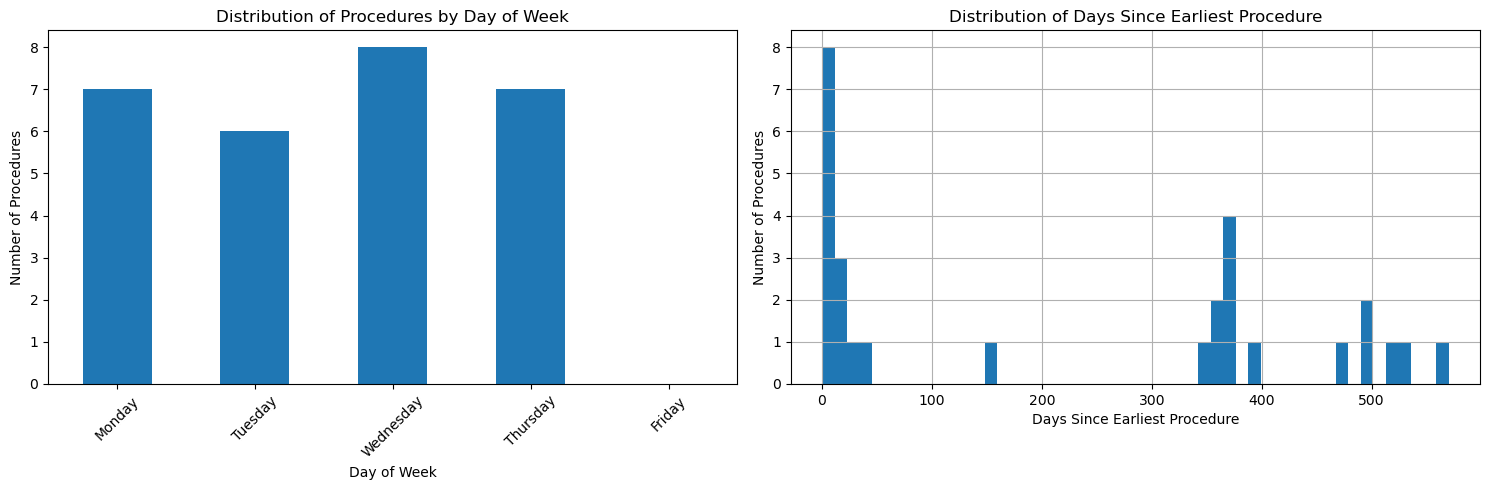

In [19]:
# Plot distribution of procedure days

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


# Plot 1: Day of week distribution
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
day_counts = metadata_df['Procedure_Day'].value_counts().reindex(day_order)

day_counts.plot(kind='bar', ax=ax1)
ax1.set_title('Distribution of Procedures by Day of Week')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Number of Procedures')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Plot 2: Days since earliest procedure
metadata_df['Days_Since_Earliest'].hist(ax=ax2, bins=50)
ax2.set_title('Distribution of Days Since Earliest Procedure')
ax2.set_xlabel('Days Since Earliest Procedure')
ax2.set_ylabel('Number of Procedures')

plt.tight_layout()
plt.show();

In [20]:
# --- Parser for Surgical Procedures (including explicit identification of uncertainties) ---

# ------------------------------------------------------------------
# 1.  Standardise / clean the free-text
# ------------------------------------------------------------------
def clean_term(term_val: str) -> str:
    """Cleans and normalises a surgical procedure term (free text)."""
    if pd.isna(term_val) or not isinstance(term_val, str):
        return ""

    term = term_val.lower()

    # --- canonicalise obvious synonyms / typos --------------------
    term = (term.replace("/", " ")
                 .replace(",", " ")
                 .replace(";", " "))

    term = (term.replace("robotic assisted", "robotic")
                 .replace("robotic-assisted", "robotic")
                 .replace("laparoscopic-assisted robotic", "robotic"))

    term = term.replace("sentinel lymph node", "sln")

    term = term.replace("sacrocolpolpexy", "sacrocolpopexy")  # fix common typo

    # --- squeeze multiple spaces to one and trim ------------------
    term = re.sub(r"\s+", " ", term).strip()
    return term


# ------------------------------------------------------------------
# 2.  Classification logic
# ------------------------------------------------------------------
def classify_surgery_detailed(term_val: str) -> dict[str, str]:
    """
    Classifies a cleaned surgical text description into our flag set.
    Returns a dict where each key flagged "Y" is TRUE for that case.
    """
    classifications: dict[str, str] = {}
    term = clean_term(term_val)
    if not term:
        return classifications

    # ----------------------------------------------------------------
    # 2A.  Surgical approach
    # ----------------------------------------------------------------
    # ► conventional (not robotic) and robotic laparoscopic and open
    if any(key in term for key in ("robotic", "ratlh", "ralh", "ralth")):
        classifications["Approach_Laparoscopic_Robotic"] = "Y"

    elif "total abdominal" in term or "tah" in term:
        classifications["Approach_Open"] = "Y"

    elif any(k in term for k in ("laparoscopic", "tlh", "lap ", "lsc", "lavh")):
        classifications["Approach_Laparoscopic_Conventional"] = "Y"

    # ----------------------------------------------------------------
    # 2B.  Extent / concurrent procedures
    # ----------------------------------------------------------------
    hysterectomy_kws      = {"hysterectomy", "removal of uterus",
                             "tlh", "lavh", "ralh", "ratlh", "ralth", "lsh", "tah"}

    cancer_kws            = {"sln", "lymph node", "pelvic washings"}

    # --- hysterectomy -------------------------------------------------
    if any(kw in term for kw in hysterectomy_kws):
        classifications["Is_Hysterectomy_Performed"] = "Y"

    # --- cancer staging --------------------------------------------------------
    if any(kw in term for kw in cancer_kws):
        classifications["Is_Cancer_Staging_Procedure"] = "Y"

    return classifications

In [21]:
# First, ensure all classification columns exist in metadata_df
surgical_classification_columns = sorted([
    'Approach_Open', 'Approach_Laparoscopic_Conventional', 'Approach_Laparoscopic_Robotic',
    'Is_Hysterectomy_Performed', 'Is_Cancer_Staging_Procedure'
])

# Initialize classification columns with 'N' if they don't exist
for col in surgical_classification_columns:
    if col not in metadata_df.columns:
        metadata_df[col] = 'N'

# Apply classifications to the metadata DataFrame
for index, row in metadata_df.iterrows():
    procedure_term = row.get('Procedure_Type')
    if pd.notna(procedure_term):  # Only process if procedure term exists
        classifications_to_set = classify_surgery_detailed(procedure_term)

        for col_name, value in classifications_to_set.items():
            if col_name in metadata_df.columns:
                metadata_df.loc[index, col_name] = value

print("Detailed surgical classification complete for metadata.")


Detailed surgical classification complete for metadata.


/tmp/ipykernel_1728733/4230139164.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(approach_counts.index, rotation=45, ha='right')
/tmp/ipykernel_1728733/4230139164.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(procedure_counts.index, rotation=45, ha='right')


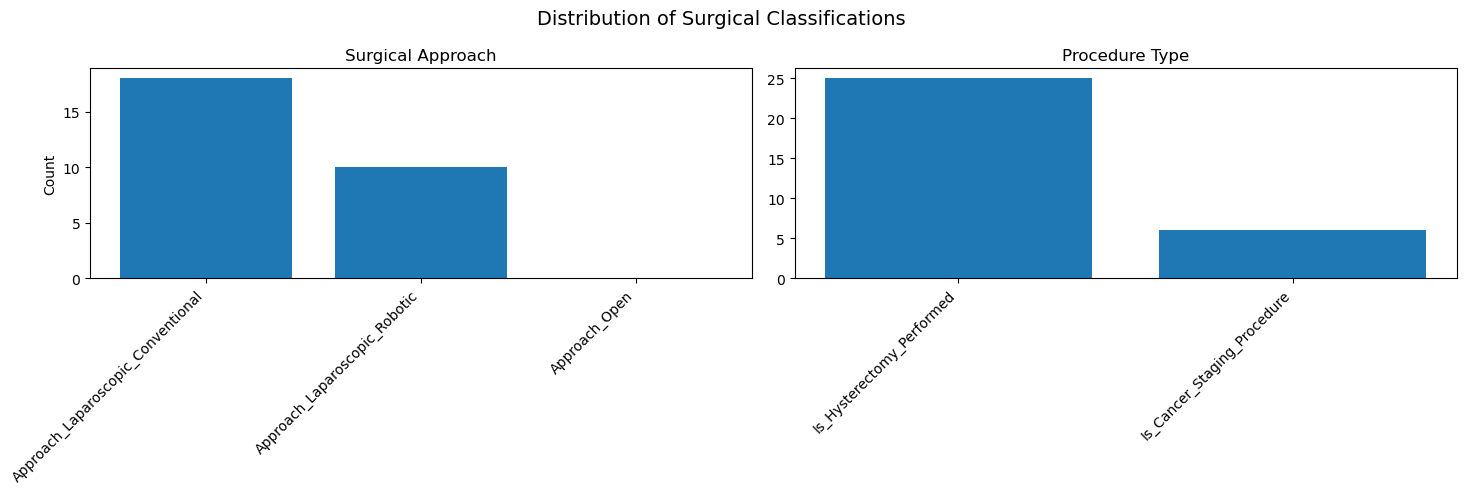


Summary Statistics:

Surgical Approach Distribution:
Approach_Laparoscopic_Conventional    18
Approach_Laparoscopic_Robotic         10
Approach_Open                          0
dtype: int64

Procedure Type Distribution:
Is_Hysterectomy_Performed      25
Is_Cancer_Staging_Procedure     6
dtype: int64


In [23]:
# Create a figure with subplots for different surgical classifications
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribution of Surgical Classifications', fontsize=14)

# Plot 1: Approach Type
approach_cols = [col for col in surgical_classification_columns if 'Approach_' in col]
approach_counts = metadata_df[approach_cols].apply(lambda x: (x == 'Y').sum())
axes[0].bar(approach_counts.index, approach_counts.values)
axes[0].set_title('Surgical Approach')
axes[0].set_xticklabels(approach_counts.index, rotation=45, ha='right')
axes[0].set_ylabel('Count')

# Plot 2: Procedure Type
procedure_cols = [col for col in surgical_classification_columns if 'Is_' in col]
procedure_counts = metadata_df[procedure_cols].apply(lambda x: (x == 'Y').sum())
# Sort procedure counts in descending order
procedure_counts = procedure_counts.sort_values(ascending=False)
axes[1].bar(procedure_counts.index, procedure_counts.values)
axes[1].set_title('Procedure Type')
axes[1].set_xticklabels(procedure_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print("=" * 40)
print("\nSurgical Approach Distribution:")
print(approach_counts)
print("\nProcedure Type Distribution:")
print(procedure_counts)

#### Clean and encode covariates ####

In [24]:
# Create a working copy
df = metadata_df.copy()

In [25]:
# =====================================================================
# 1. CLEAN & ENCODE
# =====================================================================

# Clean units and weird chars
df = df.rename(columns={'Age(yr)': 'Age', 'BMI(kg*m^-2)': 'BMI', 'Smoking?': 'Smoking_Status_Former', 'Non-Ovarian_Cancer_State': 'NonOvarian_Cancer_State'})

# Keep BMI, drop Height and Weight
cols_to_drop = []
for col in df.columns:
    if 'Height' in col or 'Weight' in col:
        cols_to_drop.append(col)
if cols_to_drop:
    df = df.drop(cols_to_drop, axis=1)
    print(f"Dropped redundant columns: {cols_to_drop}")

# Drop Race and Ethnicity, already encoded in Simplified_Race_Ethnicity
df = df.drop(['Race', 'Ethnicity'], axis=1)

# Exclude text that has either already been encoded or is mostly incomplete metadata
text_cols = ['Diagnoses', 'Ovarian_Final_Pathology', 'Alcohol?', 'Alcohol_Details',
             'Smoking_Details', 'Drugs?', 'Drug_Details', 'PMH', 'Notes',
             'Procedure_Date', 'Procedure_Type']
text_cols_present = [col for col in text_cols if col in df.columns]
df = df.drop(text_cols_present, axis=1)
print(f"Dropped residual text that has already been encoded elsewhere or is mostly incomplete metadata: {text_cols_present}")

# =====================================================================
# 2. REMOVE INVARIANTS
# =====================================================================

invariant_cols = ['Benign_Ovarian', 'Malignant_Ovarian', 'Premalignant_Ovarian']
cols_to_remove = []

for col in invariant_cols:
    if col in df.columns:
        unique_vals = df[col].nunique()
        if unique_vals <= 1:
            cols_to_remove.append(col)
            print(f"Removing invariant column: {col} (unique values: {unique_vals})")

if cols_to_remove:
    df = df.drop(cols_to_remove, axis=1)

# =====================================================================
# 3. COLLAPSE MULTI-FLAG BLOCKS
# =====================================================================

# Drop cervical malignant (none present) and benign (exclusive to premalignant)
df.drop(columns=['Benign_Cervical', 'Malignant_Cervical'], inplace=True)

# Uterine (endometrium) Pathology, include flags for uterine pathology (malignant or premalignant) and either malignant or premalignant
uterine_flags = ['Benign_Uterine', 'Premalignant_Uterine', 'Malignant_Uterine']
if all(col in df.columns for col in uterine_flags):

    # multi-level factor
    def uterine_label(row):
        if row['Malignant_Uterine'] == 'Y':
            return 'Malignant'
        elif row['Premalignant_Uterine'] == 'Y':
            return 'Premalignant'
        else:
            return 'None'

    df['Uterine_Pathology'] = df[uterine_flags].apply(uterine_label, axis=1
                              ).astype('category')

    # drop raw columns (incl. Benign_Uterine if present)
    df.drop(columns=[c for c in uterine_flags if c in df.columns], inplace=True)

    print("Uterine_Pathology counts:",
          df['Uterine_Pathology'].value_counts().to_dict())

# Surgical Approach
approach_cols = [col for col in df.columns if col.startswith('Approach_')]
if len(approach_cols) >= 3:
    # Find the approach columns
    df['Surgical_Approach'] = (
        df[approach_cols]
        .idxmax(axis=1)
        .str.replace('Approach_', '', regex=False)
        .where(df[approach_cols].any(axis=1), 'None')
    )
    df = df.drop(approach_cols, axis=1)
    print(f"Surgical_Approach: {df['Surgical_Approach'].value_counts().to_dict()}")

# =====================================================================
# 4. HANDLE REDUNDANT NUMERIC VARIABLES
# =====================================================================

# Keep Para, drop Number_of_Children
if 'Number_of_Children' in df.columns and 'Para' in df.columns:
    df = df.drop('Number_of_Children', axis=1)
    print("Dropped Number_of_Children (redundant with Para)")

# Keep Para_Gravida_Ratio, drop Gravida
if 'Gravida' in df.columns and 'Para_Gravida_Ratio' in df.columns:
    df = df.drop('Gravida', axis=1)
    print("Dropped Gravida (kept Para_Gravida_Ratio)")

# =====================================================================
# 5. DROP SPARSE BINARY FLAGS
# =====================================================================

# Drop sparse binary flags (less than 4 samples in minority class)
binary_cols = []
for col in df.columns:
    # Check if column is binary (Y/N or 0/1)
    unique_vals = df[col].dropna().astype(str).str.strip().str.upper().unique()
    if len(unique_vals) == 2 and set(unique_vals).issubset({'Y', 'N'}):
        binary_cols.append(col)

sparse_cols = []
for col in binary_cols:
    # Normalize and convert to binary 0/1 for 'Y'/'N'
    col_data = df[col].dropna().astype(str).str.strip().str.upper()
    # Map 'Y'/'N' to 1/0
    col_data = col_data.map({'Y': 1, 'N': 0})

    # Count occurrences of each value
    value_counts = col_data.value_counts()

    # If minority class has less than 4 samples and is not a malignant or premalignant flag, mark for removal
    if len(value_counts) == 2 and value_counts.min() < 4 and 'malig' not in col.lower():
        sparse_cols.append(col)

print(f"Dropped sparse binary columns: {sparse_cols}")
df = df.drop(sparse_cols, axis=1)

Dropped redundant columns: ['Height(m)', 'Weight(kg)']
Dropped residual text that has already been encoded elsewhere or is mostly incomplete metadata: ['Diagnoses', 'Ovarian_Final_Pathology', 'Alcohol?', 'Alcohol_Details', 'Smoking_Details', 'Drugs?', 'Drug_Details', 'PMH', 'Procedure_Date', 'Procedure_Type']
Removing invariant column: Benign_Ovarian (unique values: 1)
Removing invariant column: Malignant_Ovarian (unique values: 1)
Removing invariant column: Premalignant_Ovarian (unique values: 1)
Uterine_Pathology counts: {'None': 20, 'Malignant': 6, 'Premalignant': 2}
Surgical_Approach: {'Laparoscopic_Conventional': 18, 'Laparoscopic_Robotic': 10}
Dropped Number_of_Children (redundant with Para)
Dropped Gravida (kept Para_Gravida_Ratio)
Dropped sparse binary columns: ['Endometrial_Thickening', 'Symptom_Bleeding', 'Is_Hysterectomy_Performed']


#### Covariate collinearity analysis ####

In [26]:
# Categorize columns by data type
categorical_cols = []
numerical_cols = []

for col in df.columns:
    dtype = df[col].dtype
    if dtype == 'object' or dtype.name == 'category':
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print("Categorical columns:")
for col in categorical_cols:
    print(f"  {col}: {df[col].dtype}")

print(f"\nNumerical columns ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  {col}: {df[col].dtype}")

print(f"\nSummary: {len(categorical_cols)} categorical, {len(numerical_cols)} numerical columns")

Categorical columns:
  SenNet_ID: object
  NonOvarian_Cancer_State: object
  Smoking_Status_Former: object
  Simplified_Race_Ethnicity: object
  Ovarian_Specific_Benign_Finding: object
  Pelvic_Organ_Prolapse: object
  Premalignant_Cervical: object
  Urinary_Incontinence: object
  Procedure_Day: object
  Is_Cancer_Staging_Procedure: object
  Uterine_Pathology: category
  Surgical_Approach: object

Numerical columns (5):
  Age: int64
  BMI: float64
  Para: int64
  Para_Gravida_Ratio: float64
  Days_Since_Earliest: int64

Summary: 12 categorical, 5 numerical columns


In [27]:
# ---------- helpers (unchanged except safe wrappers) ----------
def _safe_spearman(x, y):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ss.ConstantInputWarning)
        rho, _ = ss.spearmanr(x, y, nan_policy='omit')
    return rho

def _safe_pointbiserial(g, v):
    mask = np.isfinite(g) & np.isfinite(v)
    if mask.sum() < 3:          # need at least 2 per group
        return np.nan
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ss.ConstantInputWarning)
        r, _ = ss.pointbiserialr(g[mask], v[mask])
    return r

def phi_signed_biascorr(x, y):
    """
    Bergsma-Wicher bias-corrected, signed φ for 2×2 tables.
    Returns NaN if table is not 2×2 or degenerate.
    """
    tbl = pd.crosstab(x, y, dropna=True)
    if tbl.shape != (2, 2):
        return np.nan

    # cell counts
    a, b, c, d = tbl.to_numpy().flatten()
    n = a + b + c + d
    if n <= 1:
        return np.nan

    # raw signed φ
    num = a * d - b * c
    den = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
    if den == 0:
        return np.nan
    phi_raw = num / den

    # bias-correction (k−1)(r−1)=1   and  n→n−1
    chi2 = ss.chi2_contingency(tbl, correction=False)[0]
    phi2_corr = max(0, (chi2 - 1) / (n - 1))
    return np.sign(phi_raw) * np.sqrt(phi2_corr)

def cramers_v_biascorr(x, y):
    """
    Bergsma-Wicher corrected Cramér’s V (always positive).
    Falls back to φ correction when table is 2×2.
    """
    tbl = pd.crosstab(x, y, dropna=True)
    r, k = tbl.shape
    if r < 2 or k < 2:
        return np.nan
    if (r, k) == (2, 2):
        return abs(phi_signed_biascorr(x, y))   # magnitude only

    chi2 = ss.chi2_contingency(tbl, correction=False)[0]
    n = tbl.to_numpy().sum()
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min((k_corr - 1), (r_corr - 1))
    return np.sqrt(phi2_corr / denom) if denom else np.nan

def correlation_ratio(cat, num):
    df = pd.DataFrame({'cat': cat, 'num': num}).dropna()
    if df['cat'].nunique() < 2: return np.nan
    grand = df['num'].mean()
    ss_between = ((df.groupby('cat', observed=False)['num'].mean() - grand)**2 *
                  df.groupby('cat', observed=False).size()).sum()
    ss_total = ((df['num'] - grand)**2).sum()
    return ss_between / ss_total if ss_total else np.nan

def is_binary(s):
    return pd.Series(s).dropna().nunique() == 2

# ---------- master ----------
def mixed_corr(df: pd.DataFrame):
    """
    Returns:
      * corr_mat  – symmetric NxN matrix of association strengths
      * assoc_tbl – tidy DataFrame: Var1, Var2, metric, value
    """
    cols = df.columns
    n = len(cols)
    M = np.eye(n)
    records = []

    num_cols  = df.select_dtypes(include='number').columns
    binary_num = [c for c in num_cols if is_binary(df[c])]
    cat_cols = df.columns.difference(num_cols).union(binary_num)
    num_cols  = num_cols.difference(binary_num)

    for i in range(n):
        for j in range(i+1, n):
            a, b = cols[i], cols[j]
            xa, xb = df[a], df[b]

            # decide metric ---------------------------
            if   a in num_cols and b in num_cols:
                metric = 'ρ'
                val = _safe_spearman(xa, xb)

            elif ((a in num_cols and b in cat_cols) or
                  (b in num_cols and a in cat_cols)):
                num, cat = (xa, xb) if a in num_cols else (xb, xa)
                if is_binary(cat):
                    metric = 'r_pb'
                    groups = cat.astype(float)
                    val = _safe_pointbiserial(groups, num)
                else:
                    metric = 'η²'
                    val = correlation_ratio(cat, num)

            else:             # cat–cat
                if is_binary(xa) and is_binary(xb):
                    metric = 'φ'
                    val    = phi_signed_biascorr(xa, xb)
                else:
                    metric = 'V'
                    val    = cramers_v_biascorr(xa, xb)

            # fill matrix & records --------------------
            M[i, j] = M[j, i] = val
            records.append({'Var1': a, 'Var2': b,
                            'metric': metric, 'value': val})

    corr_mat = pd.DataFrame(M, index=cols, columns=cols)
    assoc_tbl = (pd.DataFrame.from_records(records)
                   .assign(abs_val=lambda d: d['value'].abs())
                   .sort_values('abs_val', ascending=False))
    return corr_mat, assoc_tbl

# ---------- utilities ----------

# signed φ for 2×2 tables
def phi_signed(x, y):
    """Return signed phi; NaN if not a 2×2 table."""
    tbl = pd.crosstab(x, y, dropna=True)
    if tbl.shape != (2, 2):
        return np.nan            # we will still compute V for larger tables
    a, b, c, d = tbl.to_numpy().flatten()
    num  = a * d - b * c
    den  = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
    return num / den if den else np.nan

def plot_assoc(corr_mat, df):
    """Two heat-maps: numeric-numeric (−1…1) and categorical block (0…1)."""
    num_cols = df.select_dtypes(include='number').columns
    cat_cols = corr_mat.columns.difference(num_cols)

    # numeric-numeric
    cm_num = corr_mat.loc[num_cols, num_cols]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_num, cmap='coolwarm', vmin=-1, vmax=1,
                cbar_kws={'label': 'Spearman / point-biserial'})
    plt.title('Numeric × Numeric'); plt.xticks(rotation=90); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

    # categorical-involving (η² & V) – use 0…1 scale
    cm_cat = corr_mat.loc[cat_cols, cat_cols]
    if not cm_cat.empty:
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_cat, cmap='Reds', vmin=0, vmax=1,
                    cbar_kws={'label': 'η² / Cramérs V/φ'})
        plt.title('Categorical × Categorical'); plt.xticks(rotation=90)
        plt.yticks(rotation=0); plt.tight_layout(); plt.show()

/tmp/ipykernel_1728733/2002933767.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot[c] = df_plot[c].replace({'N': 0, 'No': 0, 'Y': 1, 'Former': 1})
/tmp/ipykernel_1728733/2002933767.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot[c] = df_plot[c].replace({'N': 0, 'No': 0, 'Y': 1, 'Former': 1})
/tmp/ipykernel_1728733/2002933767.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fa

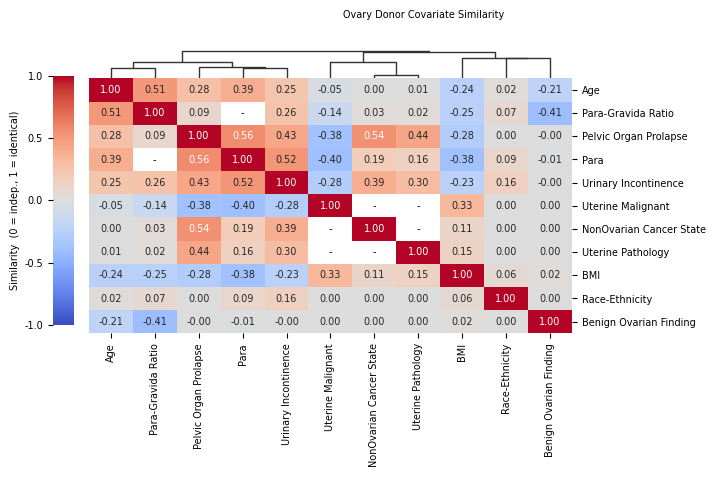

In [ ]:
# Generate a heatmap of the covariate similarity matrix
font_size = 7

# First, replace 'Other/Not Listed' values with NaN in Simplified_Race_Ethnicity
df_plot = df.copy()
df_plot['Simplified_Race_Ethnicity'] = df_plot['Simplified_Race_Ethnicity'].replace('Unknown', np.nan)

# For 'Uterine_Pathology', recode NaN to None and subset to Malignant
# Endometrial cancer has been previously reported to be negatively associated with parity,
# so stratifying by malignancy status may be informative
df_plot['Uterine_Malignant'] = df_plot['Uterine_Pathology'].apply(lambda x: 'Y' if isinstance(x, str) and 'Malignant' in x else 'N')

# Exclude sparse, singular, or derived variables not used in the correlation heatmap
df_plot = df_plot.drop(columns=['SenNet_ID', 'Procedure_Day', 'Smoking_Status_Former', 'Premalignant_Cervical',
                                'Is_Cancer_Staging_Procedure', 'Surgical_Approach', 'Days_Since_Earliest'])

# Map object-typed binary columns (e.g., 'Yes'/'No') to 0/1, keep NaN
bin_obj_cols = [c for c in df_plot.columns
                if df_plot[c].dtype == 'object' and df_plot[c].dropna().nunique() == 2]
for c in bin_obj_cols:
    df_plot[c] = df_plot[c].replace({'N': 0, 'No': 0, 'Y': 1, 'Former': 1})
    df_plot[c] = df_plot[c].where(df_plot[c].isin([0, 1]), np.nan).astype(float)

df_plot_clean = df_plot.copy()
df_plot_clean = df_plot_clean.rename(
    columns=lambda c: (
        "Race-Ethnicity" if c == "Simplified_Race_Ethnicity"
        else "Benign Ovarian Finding" if c == "Ovarian_Specific_Benign_Finding"
        else "Para-Gravida Ratio" if c == "Para_Gravida_Ratio"
        else c.replace("_", " ")
    )
)

# Compute correlation matrix and association table
corr_mat, assoc_tbl = mixed_corr(df_plot_clean)

# turn every metric to a [0,1] "similarity"
sim = corr_mat.copy()
# numeric:   |ρ| or |r_pb|
# categorical: η² or V already 0..1

# Pairs where one metadata field is derived from the other
derived_pairs = [
    ("Uterine Pathology", "Uterine Malignant"),
    ("Para", "Para-Gravida Ratio"),
    ("NonOvarian Cancer State", "Uterine Pathology"),
    ("NonOvarian Cancer State", "Uterine Malignant")
]

# Build a boolean mask for those overlaps (both directions)
mask = pd.DataFrame(False, index=sim.index, columns=sim.columns)
for a, b in derived_pairs:
    if a in mask.index and b in mask.columns:
        mask.loc[a, b] = True
    if b in mask.index and a in mask.columns:
        mask.loc[b, a] = True

# Create clustermap with coolwarm colormap
g1 = sns.clustermap(sim.fillna(0), cmap='coolwarm', linewidths=0,
                   vmin=-1, vmax=1, center=0,
                   cbar_kws={'label':'similarity  (0 = indep., 1 = identical)', 'location':'left'},
                   annot=True, fmt='.2f', annot_kws={'size': font_size},
                   row_cluster=True, col_cluster=True,
                   xticklabels=True, yticklabels=True,
                   figsize=(7, 5),
                   tree_kws={'linewidth': 1},
                   dendrogram_ratio=(0, 0.1),
                   mask=mask
                   )

# Draw "-" where masked
data = g1.data2d  # clustered order
for i, r in enumerate(data.index):
    for j, c in enumerate(data.columns):
        if mask.loc[r, c]:
            g1.ax_heatmap.text(j + 0.5, i + 0.5, "-", ha="center", va="center", color="black", fontsize=font_size)

g1.figure.suptitle('Ovary Donor Covariate Similarity', fontsize=font_size, y=1.05)

# Set colorbar label font size larger and adjust position to the left
#g1.cax.yaxis.set_label_position('left')
g1.cax.set_ylabel('Association strength', fontsize=font_size, rotation=90, labelpad=3)

# Set colorbar ticks at increments of 0.5 and increase tick label size
cbar_ticks = np.arange(-1.0, 1.01, 0.5)
g1.cax.set_yticks(cbar_ticks)
g1.cax.set_yticklabels([f"{x:.1f}" for x in cbar_ticks], fontsize=font_size)

# Increase font sizes for tick labels
g1.ax_heatmap.tick_params(axis='both', which='major', labelsize=font_size)
g1.ax_col_dendrogram.tick_params(axis='both', which='major', labelsize=font_size)
g1.ax_row_dendrogram.tick_params(axis='both', which='major', labelsize=font_size)

# Increase colorbar tick label size
g1.cax.tick_params(axis='both', which='major', labelsize=font_size)

# Adjust colorbar position
g1.cax.set_position([-0.03, 0.42, 0.03, 0.498]);

plt.savefig(f"{python_analyses_dir}/paper_figs/HumOvaryAtlas_donor_covariate_association.pdf", format='pdf', dpi=500, bbox_inches='tight')
plt.show();

In [35]:
print("="*60)
print("COVARIATE CORRELATION ANALYSIS SUMMARY")
print("="*60)

print(f"Total variables analysed: {len(corr_mat.columns)}")
print(f"Total pairwise associations: {len(assoc_tbl)}")

# Count by metric type
metric_name = {'ρ': 'Spearman ρ  (num–num)',
               'r_pb': 'Point-biserial (bin–num)',
               'η²': 'Eta² (cat–num)',
               'V':  "Cramér’s V  (cat–cat)",
               'φ':  "Phi φ (2×2)"}

# Exclude rows where Var1 or Var2 are in derived_pairs
assoc_tbl = assoc_tbl[~assoc_tbl.apply(lambda row: (row['Var1'], row['Var2']) in derived_pairs or (row['Var2'], row['Var1']) in derived_pairs, axis=1)]

print("\nAssociation types:")
for m, n in assoc_tbl['metric'].value_counts().items():
    print(f"  {metric_name[m]}: {n}")

# Classify strength ----------------------------------------------------

# metrics that can be negative
signed_metrics = {'ρ', 'r_pb', 'φ'}

#  Effect size conventions (Cohen 1988; Richardson 2011; Rea & Parker 1992)
STRONG = {'ρ': .55, 'r_pb': .55, 'η²': .18, 'φ': .60, 'V': .35}
MODERATE = {'ρ': .35, 'r_pb': .35, 'η²': .08, 'φ': .40, 'V': .22}

def label_strength(row):
    val = abs(row['value']) if row['metric'] in signed_metrics else row['value']
    if val >= STRONG[row['metric']]:
        return 'Strong'
    elif val >= MODERATE[row['metric']]:
        return 'Moderate'
    elif val >= 0.20:
        return 'Weak-Moderate'
    else:
        return 'Weak'

assoc_tbl['strength'] = assoc_tbl.apply(label_strength, axis=1)

print("\nDistribution of association strengths:")
for level in ['Strong', 'Moderate', 'Weak-Moderate', 'Weak']:
    print(f"  {level}: {(assoc_tbl['strength'] == level).sum()}")

# List specifics -------------------------------------------------------
for level in ['Strong', 'Moderate']:
    subset = assoc_tbl[assoc_tbl['strength'] == level]
    if not subset.empty:
        print(f"\n{level} associations ({level.lower()} threshold):")
        for _, r in subset.iterrows():

            # choose a numeric format (include sign for signed metrics)
            fmt = "{:+.3f}" if r['metric'] in signed_metrics else "{:.3f}"
            val_str = fmt.format(r['value'])

            print(f"     {r['Var1']} ↔ {r['Var2']}: {val_str} ({r['metric']})")

print("\n" + "="*60)

COVARIATE CORRELATION ANALYSIS SUMMARY
Total variables analysed: 11
Total pairwise associations: 55

Association types:
  Point-biserial (bin–num): 16
  Cramér’s V  (cat–cat): 12
  Eta² (cat–num): 12
  Phi φ (2×2): 6
  Spearman ρ  (num–num): 5

Distribution of association strengths:
  Strong: 5
  Moderate: 12
  Weak-Moderate: 11
  Weak: 23

Strong associations (strong threshold):
     Para ↔ Pelvic_Organ_Prolapse: +0.564 (r_pb)
     NonOvarian_Cancer_State ↔ Pelvic_Organ_Prolapse: 0.544 (V)
     Pelvic_Organ_Prolapse ↔ Uterine_Pathology: 0.438 (V)
     NonOvarian_Cancer_State ↔ Urinary_Incontinence: 0.392 (V)
     NonOvarian_Cancer_State ↔ Para: 0.186 (η²)

Moderate associations (moderate threshold):
     Para ↔ Urinary_Incontinence: +0.522 (r_pb)
     Age ↔ Para_Gravida_Ratio: +0.507 (ρ)
     Pelvic_Organ_Prolapse ↔ Urinary_Incontinence: +0.430 (φ)
     Para_Gravida_Ratio ↔ Ovarian_Specific_Benign_Finding: -0.409 (r_pb)
     Para ↔ Uterine_Malignant: -0.397 (r_pb)
     Age ↔ Para: +0.

In [36]:
# No strong, unexpected associations found. Some moderate associations with variables of interest -> review these critically during downstream analyses.

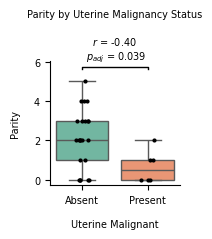

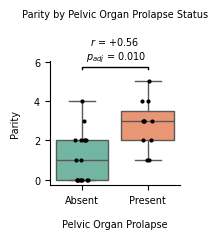

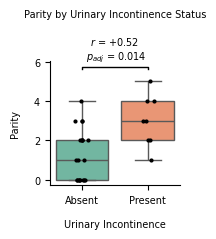

In [38]:
# Plot parity correlation with clinical covariates that have been previously reported to be associated with parity

font_size = 7

# In case Para is not numeric, convert it just in case
df_plot['Para'] = pd.to_numeric(df_plot['Para'], errors='coerce')

analysis_pairs = [
    {
        "label": "Uterine Malignancy",
        "col": None,
        "lookup_substrs": ['Uterine_Malignant'],
        "plot_title": "Parity by Uterine Malignancy Status",
        "ylabel": "Parity"
    },
    {
        "label": "Pelvic Organ Prolapse",
        "col": None,
        "lookup_substrs": ['Pelvic_Organ_Prolapse'],
        "plot_title": "Parity by Pelvic Organ Prolapse Status",
        "ylabel": "Parity"
    },
    {
        "label": "Urinary Incontinence",
        "col": None,
        "lookup_substrs": ['Urinary_Incontinence'],
        "plot_title": "Parity by Urinary Incontinence Status",
        "ylabel": "Parity"
    }
]

# Calculate p-values and effect sizes using the custom safe_rank_biserial function ahead of plotting
for analysis in analysis_pairs:
    # Try to find the relevant column
    target_col = None
    for substr in analysis["lookup_substrs"]:
        for c in df_plot.columns:
            if substr in c:
                target_col = c
                break

    analysis["col"] = target_col

    grouping = df_plot[target_col]
    yvals = df_plot["Para"]

    mask = grouping.notnull() & yvals.notnull()
    group0 = yvals[(grouping == 0) & mask]
    group1 = yvals[(grouping == 1) & mask]

    n0 = len(group0)
    n1 = len(group1)

    # Mann-Whitney U test for continuous vs binary
    stat, pval = ss.mannwhitneyu(group0, group1, alternative='two-sided')

    # Extract rank_biserial from assoc_tbl if available
    assoc_row = assoc_tbl[
        ((assoc_tbl["Var1"] == "Para") & (assoc_tbl["Var2"] == target_col)) |
        ((assoc_tbl["Var2"] == "Para") & (assoc_tbl["Var1"] == target_col))
    ]
    if not assoc_row.empty:
        rank_biserial = assoc_row[assoc_row["metric"].isin(["r_pb", "rank_biserial"])]["value"].values
        rank_biserial = rank_biserial[0] if len(rank_biserial) > 0 else float('nan')
    else:
        rank_biserial = float('nan')

    analysis["pval"] = pval
    analysis["rank_biserial"] = rank_biserial
    analysis["group0_n"] = n0
    analysis["group1_n"] = n1


# Adjust p-values for multiple comparisons using Benjamini-Hochberg
# Calculate adjusted p-values (Benjamini-Hochberg) for all analyses
all_pvals = [a["pval"] for a in analysis_pairs]
_, bh_adj_pvals, _, _ = multipletests(all_pvals, method='fdr_bh')
for i, analysis in enumerate(analysis_pairs):
    analysis["pval_adj"] = bh_adj_pvals[i]

# Plot parity correlation with binary covariates
for analysis in analysis_pairs:
    target_col = analysis["col"]

    # Recode 0 → "Absent", 1 → "Present" for plotting
    df_plot[f"{target_col}_present_absent"] = df_plot[target_col].replace({0: "Absent", 1: "Present"})

    # Ensure 'Absent' is always first in plot order using categorical dtype
    present_absent_col = f"{target_col}_present_absent"
    df_plot[present_absent_col] = pd.Categorical(
        df_plot[present_absent_col],
        categories=["Absent", "Present"],
        ordered=True
    )

    plt.figure(figsize=(2,2.5))

    ax = sns.boxplot(
        data=df_plot,
        x=present_absent_col,
        y='Para',
        showfliers=True,
        palette='Set2',
        hue=present_absent_col,
        order=["Absent", "Present"],
        legend=False
    )

    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False) # Remove the top and right spines/borders

    # Add padding between x/y axis labels and ticks
    ax.xaxis.labelpad = 10; ax.yaxis.labelpad = 10  # Padding between x-label & y-label and ticks (in points)

    sns.stripplot(
        data=df_plot,
        x=present_absent_col,
        y='Para',
        color='k', alpha=1, jitter=True,
        order=["Absent", "Present"],
        size=3
    )

    plt.xlabel(target_col.replace("_", " "), fontsize=font_size); plt.ylabel(analysis["ylabel"], fontsize=font_size)

    ax.tick_params(axis='x', labelsize=font_size); ax.tick_params(axis='y', labelsize=font_size) # Increase tick size for both x and y axes
    plt.title(analysis["plot_title"], pad=32, fontsize=font_size)

    # --- Add significance bar ---
    # Use stats already computed above, only if both groups are present
    pval_adj = analysis.get("pval_adj", None); r_pb = analysis.get("rank_biserial", None); n0 = analysis.get("group0_n", 0); n1 = analysis.get("group1_n", 0)

    # Only annotate if there are both Absent and Present groups with >0 members
    if (n0 > 0) and (n1 > 0) and (r_pb is not None) and (pval_adj is not None):
        # Stat bar parameters
        x1, x2 = 0, 1  # bar positions for 'Absent' and 'Present'
        y_vals = df_plot['Para']
        y_max = y_vals.max() if y_vals.notnull().any() else 1
        y_min = y_vals.min() if y_vals.notnull().any() else 0
        y_range = y_max - y_min
        bar_height = y_max + 0.13*y_range  # position the bar a bit above max
        text_height = y_max + 0.18*y_range

        # Determine annotation text from p-value and r_pb, include "+" or "-" before r_pb
        annot = f"$\\it{{r}}$ = {r_pb:+.2f}\n $p_{{adj}}$ = {pval_adj:.3f}"

        # Add the line/bar and the significance annotation while plotting
        ax.plot([x1, x1, x2, x2], [bar_height, bar_height+0.015*y_range, bar_height+0.015*y_range, bar_height], lw=1, c='k')
        ax.text((x1 + x2) / 2, text_height, annot, ha='center', va='bottom', color='k', fontsize=font_size)
    # --- End significance bar ---
    #plt.savefig(f"{python_analyses_dir}/paper_figs/HumOvaryAtlas_Parity-{analysis['lookup_substrs'][0]}-DonorCorr.pdf", format='pdf', dpi=500, bbox_inches='tight')
    plt.tight_layout()
    plt.show();

#### Cohort display plots ####

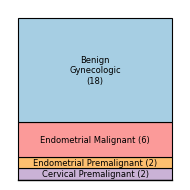

In [16]:
# Define labels and corresponding logic for "clinical indication for oophorectomy" and make fig
font_size = 6
def clinical_indication(row):
    if row['Premalignant_Cervical'] == 'Y':
        return "Cervical Premalignant"
    elif row['Uterine_Pathology'] == 'Premalignant':
        return "Endometrial Premalignant"
    elif row['Uterine_Pathology'] == 'Malignant':
        return "Endometrial Malignant"
    else:
        return "Benign Gynecologic"

df_tmp = df.copy()

# If column names are not exactly the above, adapt to your dataframe
df_tmp['Clinical_Indication'] = df_tmp.apply(clinical_indication, axis=1)

indications = [
    "Cervical Premalignant",
    "Endometrial Premalignant",
    "Endometrial Malignant",
    "Benign Gynecologic"
]
counts = [sum(df_tmp['Clinical_Indication'] == ind) for ind in indications]

fig, ax = plt.subplots(figsize=(2, 2))

y_bottom = 0
colors = [
    '#cab2d6',  # Cervical premalignant – muted lavender
    '#fdbf6f',  # Endometrial premalignant – warm pastel gold
    '#fb9a99',  # Endometrial malignant – soft salmon
    '#a6cee3'   # Benign gynecologic – calm pastel blue
]

bar_width = 1

for i, (ind, count, color) in enumerate(zip(indications, counts, colors)):
    bar = ax.bar(0, count, bottom=y_bottom, color=color, label=ind, width=bar_width, edgecolor='black', linewidth=0.8)
    if count > 0:
        if count < 10:
            # No wrapping for any, "(count)" on same line as label
            txt = f"{ind} ({count})"
        else:
            # For n >= 5, wrapping allowed and (count) on separate line
            wrapped_label = fill(ind, width=14)
            txt = f"{wrapped_label}\n({count})"
        ax.text(
            0,
            y_bottom + count / 2 - 0.1,
            txt,
            ha='center', va='center',
            color='black', fontsize=font_size
        )
    y_bottom += count

# Set title
#ax.set_title('Clinical Indication for Oophorectomy', fontsize=font_size)

# Remove x ticks and x tick labels
ax.set_xticks([]); ax.set_xticklabels([])

# Style the x axis line (bottom spine) as solid black, rest invisible
ax.spines['left'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False); ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black'); ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_bounds(-bar_width/2, bar_width/2)
ax.yaxis.set_visible(False)

plt.savefig(f"{python_analyses_dir}/paper_figs/HumOvaryAtlas_DonorClinicalIndication.pdf", format='pdf', dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()

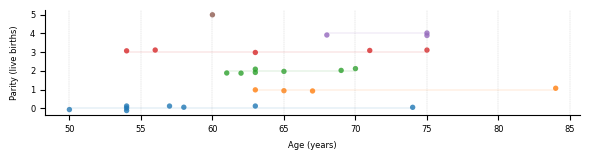

In [ ]:
# Plot Para (y axis) by Age (x axis)
font_size = 6
plt.figure(figsize=(6, 1.7))

unique_paras = sorted(df['Para'].dropna().unique())
colors = plt.cm.tab10.colors if len(unique_paras) <= 10 else plt.cm.tab20.colors
color_map = {para: colors[i % len(colors)] for i, para in enumerate(unique_paras)}

np.random.seed(4)  # For reproducibility of jitter

ax = plt.gca()

for i, para in enumerate(unique_paras):
    idx = df['Para'] == para
    sub = df.loc[idx, 'Age'].values
    # If only one value for this y-axis group, don't jitter
    if len(sub) == 1:
        y = np.full(len(sub), float(para))
    else:
        jitter = (np.random.rand(len(sub)) - 0.5) * 0.25
        y = np.full(len(sub), float(para)) + jitter
    x = sub
    ax.scatter(x, y, color=color_map[para], s=15, alpha=0.8, label=f'Para {para}' if i == 0 else None,
               linewidths=0, edgecolors='none')

    # Connect the same parity values with same colored line for easy viewing
    if len(sub):
        ax.plot([min(sub), max(sub)], [para, para], color=color_map[para], linewidth=0.25, alpha=0.5)

# Set y-axis ticks to increment by 1
min_para = int(min(unique_paras))
max_para = int(max(unique_paras))
ax.set_yticks(np.arange(min_para, max_para + 1, 1))

# Set increased font sizes for labels, title, and ticks, and add padding between labels and axes
ax.set_xlabel('Age (years)', fontsize=font_size, labelpad=5)
ax.set_ylabel('Parity (live births)', fontsize=font_size, labelpad=8)
#ax.set_title('Donor Parity vs. Age', fontsize=font_size)
ax.tick_params(axis='both', which='major', labelsize=font_size)
# Only draw vertical gridlines (no y-axis gridlines)
ax.grid(axis='x', linestyle='--', alpha=0.8, linewidth=0.25)
# Hide top and right border lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(f"{python_analyses_dir}/paper_figs/HumOvaryAtlas_DonorParityAge.pdf", format='pdf', dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show();

#### Export donor covariates ####

In [ ]:
# Save the cleaned dataframe as a TSV file
df.to_csv(f"{nostromo_datadir}/dispersed_donor_covariates_cleaned.tsv", sep='\t', index=False)
df

#### Session Info ####

In [34]:
get_session_info()

2025-11-02 21:52:30.199733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762149150.213918 4104112 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762149150.218165 4104112 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762149150.230627 4104112 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762149150.230640 4104112 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762149150.230641 4104112 computation_placer.cc:177] computation placer alr

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.26.4 scipy==1.14.1 pandas==2.2.3 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13
traitlets version: 5.14.3
jupyter_core version: 5.7.2
datetime version: 5.5
tornado version: 6.4.1
six version: 1.16.0
platformdirs version: 4.2.2
importlib.resources version: 6.4.4
importlib.metadata version: 8.4.0
jupyter_client version: 8.6.2
ipykernel version: 6.29.5
executing version: 2.0.1
asttokens version: 2.4.1
pure_eval version: 0.2.3
stack_data version: 0.6.2
pygments version: 2.18.0
pickleshare version: 0.7.5
decorator version: 5.1.1
wcwidth version: 0.2.13
prompt_toolkit version: 3.0.47
parso version: 0.8.4
jedi version: 0.19.1
IPython version: 8.26.0
comm version: 0.2.2
psutil version: 6.0.0
packaging version: 24.1
debugpy version: 1.8.5
ipywidgets version: 8.1.5
numpy version: 1.26.4
defusedxml version: 0.7.1
cffi version: 1.17.0
pyparsing version: 3.1.4
cycler version: 0.12.1
kiwisolver version: 1.4.5
matplotlib 